<a href="https://colab.research.google.com/github/bhavyacloud29/Beginner-Python-projects/blob/main/DUPLICATE-QUESTION-PAIRS/NLP_Question_answer_pairs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("quora/question-pairs-dataset")

Using Colab cache for faster access to the 'question-pairs-dataset' dataset.


In [ ]:
path

'/kaggle/input/question-pairs-dataset'

In [ ]:
import os
os.listdir(path)

['questions.csv']

In [ ]:
!pip install beautifulsoup4

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
import re
import string
import nltk
from bs4 import BeautifulSoup
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
path

'/kaggle/input/question-pairs-dataset'

In [ ]:
df=pd.read_csv('/kaggle/input/question-pairs-dataset/questions.csv')
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [ ]:
df['question1'][0]

'What is the step by step guide to invest in share market in india?'

In [ ]:
df['question2'][0]

'What is the step by step guide to invest in share market?'

In [ ]:
df.shape

(404351, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [ ]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
281738,281738,553829,553830,What kind of secret you can't share with anyon...,What secret can you not share with anyone?,1
121206,121206,240195,240196,Share your review about Kabali movie?,What is your review of Kabali (2016 movie)?,1
61156,61156,121632,121633,What is the official language of the United St...,"Why is there no ""official"" language for the Un...",0
191310,191310,377684,377685,Why does Elon Musk consider himself as an engi...,How can Elon Musk call himself an engineer?,1
278574,278574,547680,547681,Does the Moon spin on its axis?,Does moon revolve around its own axis?,1
99861,99861,198164,198165,Who really shot John F. Kennedy?,Who killed JFK (President John F. Kennedy)?,1
292886,292886,575398,575399,Can I play wynk music files in another player?,Is there a method to play the songs saved offl...,1
18212,18212,36339,36340,Does love and relationship comes after sex?,What is importance of sex in life?,0
32495,32495,64766,64767,Where do blizzards usually occur and why?,Where do blizzards occur in the U.S.? Why?,0
368450,368450,721086,721087,What is the best way to flush methamphetamines...,How can I dilute meth out of my system?,1


In [ ]:
# missing values
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

is_duplicate
0    255042
1    149306
Name: count, dtype: int64
is_duplicate
0    63.074876
1    36.925124
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

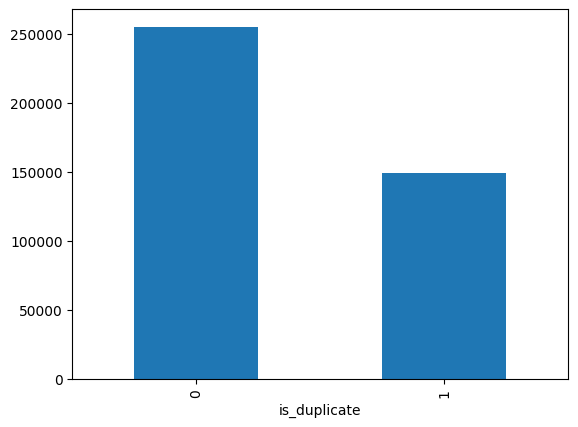

In [ ]:
# Duplicate and Non-duplicate questions Distribution
print(df['is_duplicate'].value_counts())
print(df['is_duplicate'].value_counts()*100/df['is_duplicate'].count())

df['is_duplicate'].value_counts().plot(kind='bar')

In [ ]:
qid=pd.Series(df['qid1'].tolist()+df['qid2'].tolist())
print("No of unique questions",np.unique(qid).shape[0])

x=qid.value_counts()>1
print("No of duplicate questions",x[x].shape[0])

No of unique questions 789795
No of duplicate questions 13698


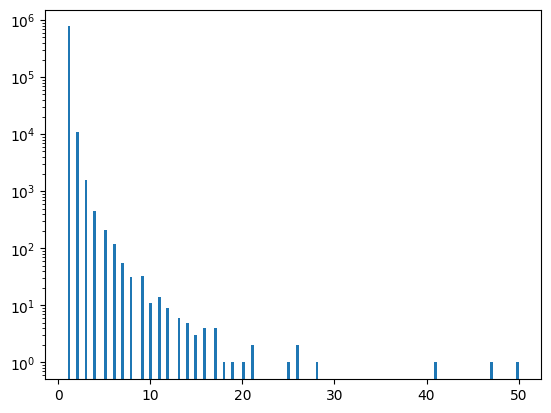

In [ ]:
# repeated questions
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')

In [ ]:
 # Simplest approach - Bag of words on qid1,qid2 and isduplicate works as the target column
new_df=df.sample(10000)
new_df.isnull().sum()


,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


In [ ]:
new_df.shape

(10000, 6)

In [ ]:
new_df=new_df[['question1','question2','is_duplicate']]


In [ ]:
questions=list(new_df['question1'])+list(new_df['question2'])
cv=CountVectorizer(max_features=3000)
q1arr,q2arr=np.vsplit(cv.fit_transform(questions).toarray(),2)

In [ ]:
len(questions)

20000

In [ ]:
q=cv.fit_transform(questions)

In [ ]:
q.toarray().shape  # It is 10000 dimensional shape

(20000, 3000)

In [ ]:
q1arr.shape,q2arr.shape

((10000, 3000), (10000, 3000))

In [ ]:
temp_df1=pd.DataFrame(q1arr,index=new_df.index)
temp_df2=pd.DataFrame(q2arr,index=new_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(10000, 6000)

In [ ]:
temp_df['is_duplicate']=new_df['is_duplicate']
temp_df.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
141767,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
265607,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
135903,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
317388,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
116797,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape



((8000, 6000), (2000, 6000), (8000,), (2000,))

In [ ]:
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print("Accuracy score",accuracy_score(y_test,y_pred))
print("Confusion matrix",confusion_matrix(y_test,y_pred))
print("Classification report",classification_report(y_test,y_pred))


Accuracy score 0.7225
Confusion matrix [[1161   96]
 [ 459  284]]
Classification report               precision    recall  f1-score   support

           0       0.72      0.92      0.81      1257
           1       0.75      0.38      0.51       743

    accuracy                           0.72      2000
   macro avg       0.73      0.65      0.66      2000
weighted avg       0.73      0.72      0.70      2000



In [ ]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)
print("Accuracy score",accuracy_score(y_test,y_pred))
print("Classification report",classification_report(y_test,y_pred))
print("Confusion Matrix",confusion_matrix(y_test,y_pred))


Accuracy score 0.708
Classification report               precision    recall  f1-score   support

           0       0.71      0.90      0.79      1257
           1       0.69      0.39      0.50       743

    accuracy                           0.71      2000
   macro avg       0.70      0.64      0.65      2000
weighted avg       0.70      0.71      0.68      2000

Confusion Matrix [[1129  128]
 [ 456  287]]


In [ ]:
# Features created
# q1 length, q2 length
# q1 words, q2 words
# words common (No. of common unique words)
# Words total
# words share  (Words common/words total)
# 3000 BOW for question1 and 3000 BOW for question2
new_df=df.sample(30000,random_state=2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1


In [ ]:
# No. of unique questions
qid=pd.Series(new_df['qid1'].tolist()+new_df['qid2'].tolist())
print("No of unique questions",np.unique(qid).shape[0])

x=qid.value_counts()>1
print("No of duplicate questions",x[x].shape[0])


No of unique questions 59824
No of duplicate questions 156


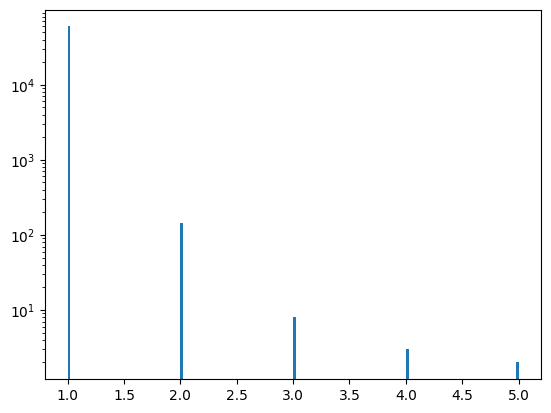

In [ ]:
#  Repeated question histogram
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')


In [ ]:
# Feature engineering
new_df['q1_len']=new_df['question1'].str.len()
new_df['q2_len']=new_df['question2'].str.len()
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0,33,44
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0,25,47
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0,125,124
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1,45,60
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1,71,84


In [ ]:
new_df['q1_num_words']=new_df['question1'].apply(lambda row:len(row.split(" ")))
new_df['q2_num_words']=new_df['question2'].apply(lambda row:len(row.split(" ")))
new_df.head()


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0,33,44,6,9
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0,25,47,4,9
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0,125,124,24,24
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1,45,60,8,10
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1,71,84,12,14


In [ ]:
def common_words(row):
  w1=set(map(lambda word:word.lower().strip(),row['question1'].split(" ")))
  w2=set(map(lambda word:word.lower().strip(),row['question2'].split(" ")))
  return len(w1&w2)
new_df['common_words']=new_df.apply(common_words,axis=1)

new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0,33,44,6,9,4
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0,25,47,4,9,0
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1,45,60,8,10,5
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1,71,84,12,14,6


In [ ]:
def total_words(text):
  w1=set(map(lambda word:word.lower().strip(),text['question1'].split(" ")))
  w2=set(map(lambda word:word.lower().strip(),text['question2'].split(" ")))
  return (len(w1)+len(w2))

new_df['total_words']=new_df.apply(total_words,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0,33,44,6,9,4,15
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0,25,47,4,9,0,13
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20,42
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1,45,60,8,10,5,18
132567,132567,262555,262556,Does Google Maps account for change in speed w...,What speed does Google Maps assume when it gen...,1,71,84,12,14,6,26


In [ ]:
new_df['word_share']=round(new_df['common_words']/new_df['total_words'],2)
new_df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words,word_share
123071,123071,243872,243873,How can you stop your Beagle Australian Shephe...,How do I stop a German Shepherd/Border Collie ...,1,84,78,14,14,5,27,0.19
208784,208784,411851,411852,What do you think of my singing?,What is the difference between bootstrap-sass ...,0,32,60,7,8,1,15,0.07
155297,155297,307129,307130,How can homosexuality be natural?,Can you explain how Homosexuality is natural?,1,33,45,5,7,4,12,0.33
306154,306154,601108,601109,What is the funniest joke in the world and why?,What is the funniest joke you've ever heard or...,0,47,52,10,10,5,19,0.26
107349,107349,212899,212900,What are a few inexpensive home decor ideas wh...,What are a few inexpensive home decor ideas wh...,1,70,69,15,14,13,29,0.45


<Axes: xlabel='word_share', ylabel='Count'>

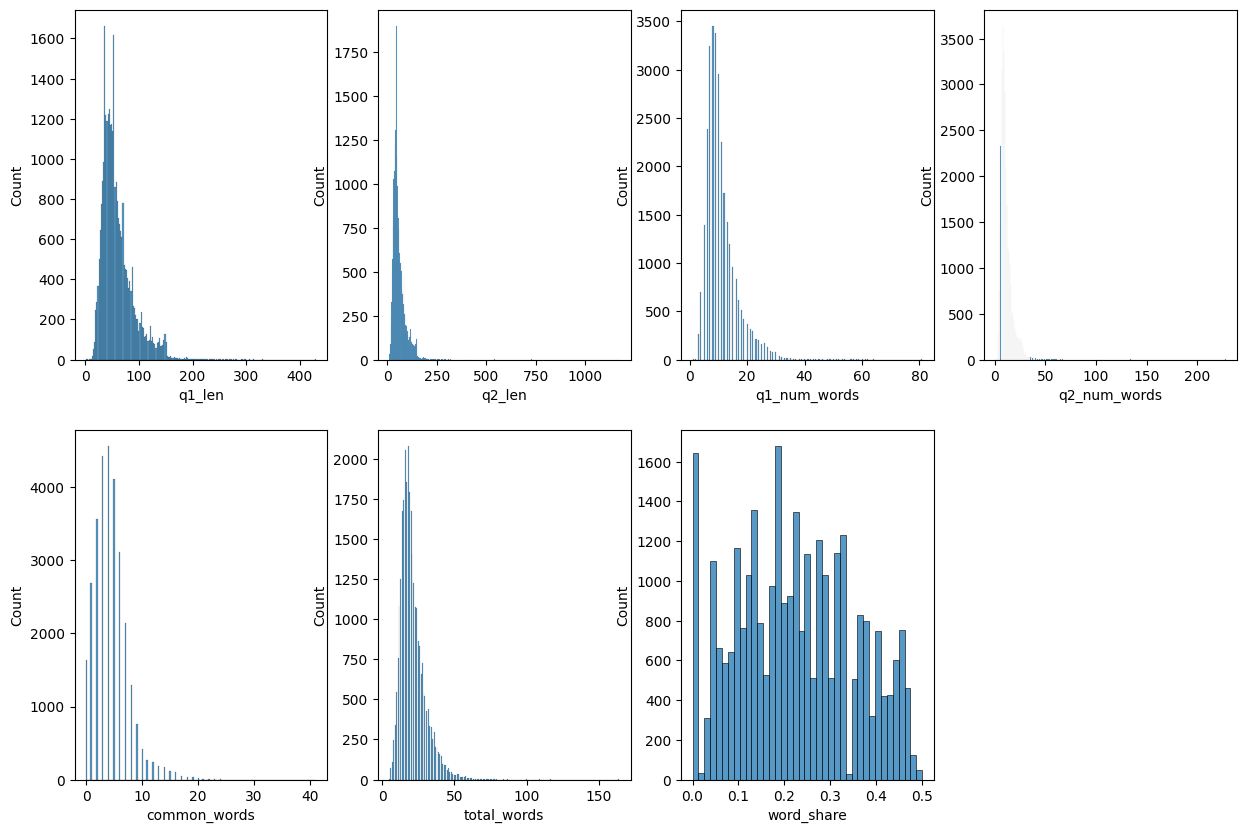

In [ ]:
# create multple axis and plot histogram for all columns
plt.figure(figsize=(15,10))
axes=plt.subplot(2,4,1)
sns.histplot(new_df['q1_len'])
axes=plt.subplot(2,4,2)
sns.histplot(new_df['q2_len'])
axes=plt.subplot(2,4,3)
sns.histplot(new_df['q1_num_words'])
axes=plt.subplot(2,4,4)
sns.histplot(new_df['q2_num_words'])
axes=plt.subplot(2,4,5)
sns.histplot(new_df['common_words'])
axes=plt.subplot(2,4,6)
sns.histplot(new_df['total_words'])
axes=plt.subplot(2,4,7)
sns.histplot(new_df['word_share'])

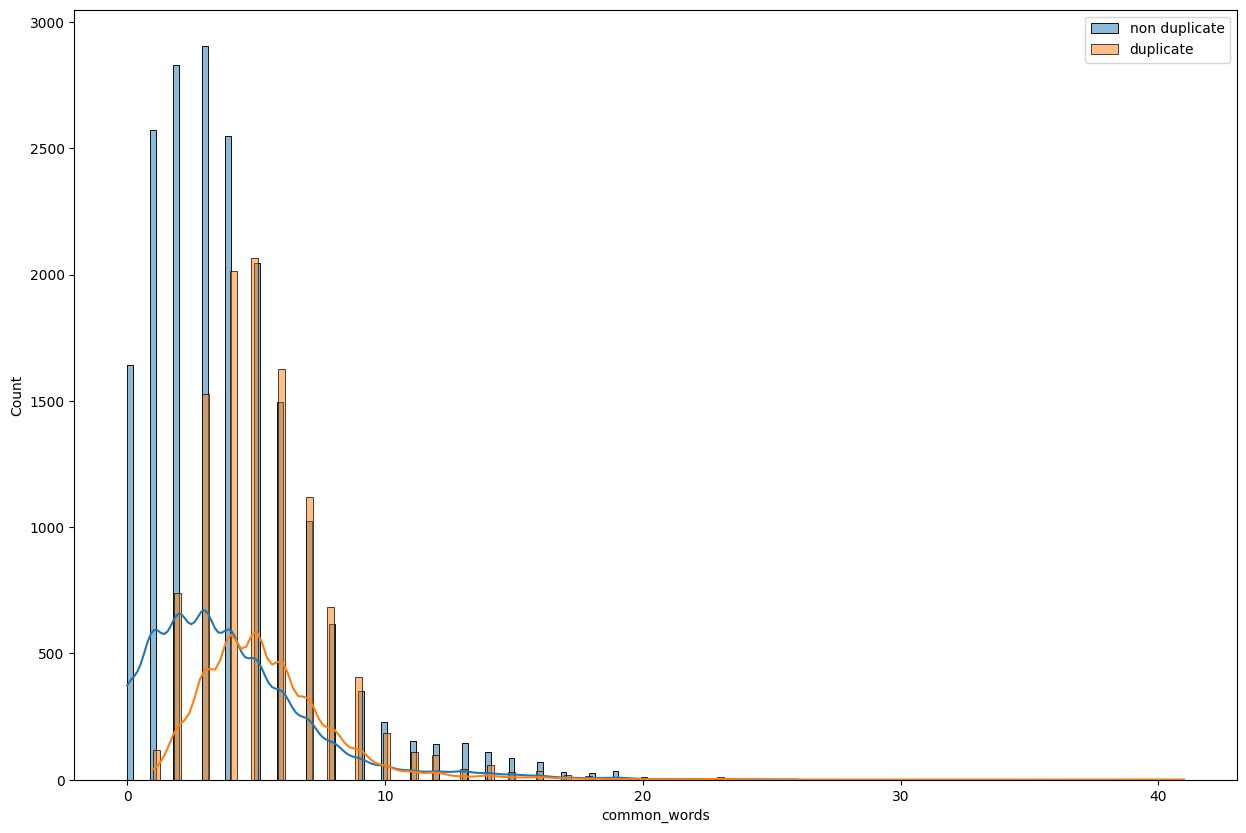

In [ ]:
# Analysis on common words
plt.figure(figsize=(15,10))
sns.histplot(new_df[new_df['is_duplicate']==0]['common_words'],label='non duplicate',kde=True)
sns.histplot(new_df[new_df['is_duplicate']==1]['common_words'],label='duplicate',kde=True)
plt.legend()
plt.show()

In [ ]:
new_df[new_df['is_duplicate']==0]

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words,word_share
302477,302477,594007,594008,What are kalman filters used for?,What are examples of filters used in a home?,0,33,44,6,9,4,15,0.27
369857,369857,723787,723788,How do Relationship work?,What matters in the life most dignity or money?,0,25,47,4,9,0,13,0.00
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0,125,124,24,24,20,42,0.48
30092,30092,59988,59989,Why do I want to cry all the time?,Why do I want to cry?,0,34,21,9,6,5,15,0.33
249446,249446,491144,491145,Where can I get professional and efficient pes...,Where can I get very safe and reliable pest se...,0,71,67,12,13,10,25,0.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...
314121,314121,1368,616492,What are the best monospace or fixed-width fon...,Are monospace or proportional fonts better for...,0,72,59,12,8,6,20,0.30
142895,142895,282814,282815,How is Christmas celebrated in Mexico?,How is Christmas celebrated?,0,38,28,6,4,3,10,0.30
43027,43027,74406,85695,How do you identify a closeted gay person?,I am a closet Christian. How do I tell my gay ...,0,42,76,8,17,4,24,0.17
154199,154199,304984,304985,What is a suitable inpatient drug and alcohol ...,What is a suitable inpatient drug and alcohol ...,0,80,81,14,14,13,28,0.46


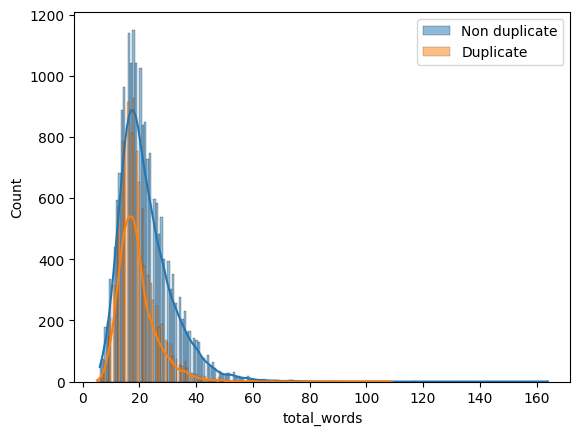

In [ ]:
sns.histplot(new_df[new_df['is_duplicate']==0]['total_words'],label="Non duplicate",kde=True)
sns.histplot(new_df[new_df['is_duplicate']==1]['total_words'],label="Duplicate",kde=True)
plt.legend()
plt.show()

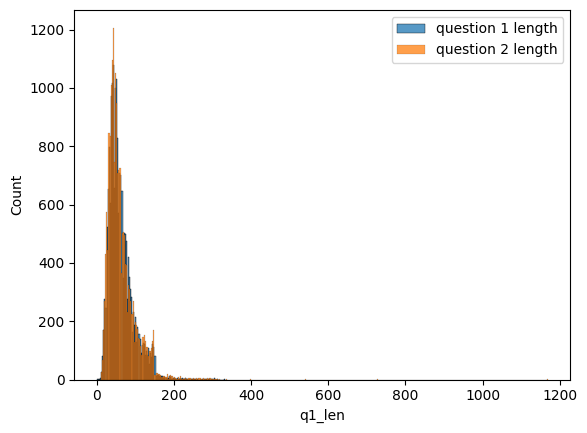

In [ ]:
sns.histplot(new_df[new_df['is_duplicate']==0]['q1_len'],label="question 1 length")
sns.histplot(new_df[new_df['is_duplicate']==0]['q2_len'],label="question 2 length")
plt.legend()
plt.show()

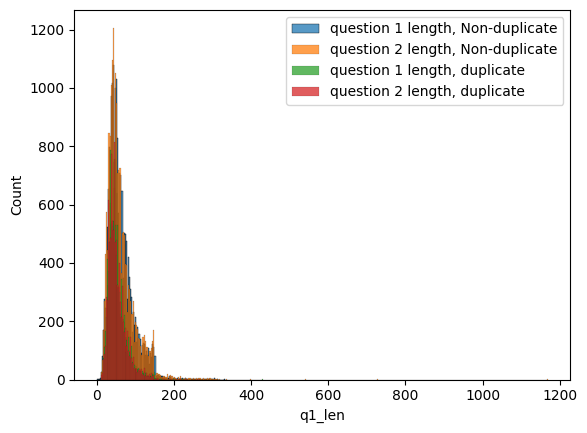

In [ ]:
sns.histplot(new_df[new_df['is_duplicate']==0]['q1_len'],label="question 1 length, Non-duplicate")
sns.histplot(new_df[new_df['is_duplicate']==0]['q2_len'],label="question 2 length, Non-duplicate")

sns.histplot(new_df[new_df['is_duplicate']==1]['q1_len'],label="question 1 length, duplicate")
sns.histplot(new_df[new_df['is_duplicate']==1]['q2_len'],label="question 2 length, duplicate")
plt.legend()
plt.show()

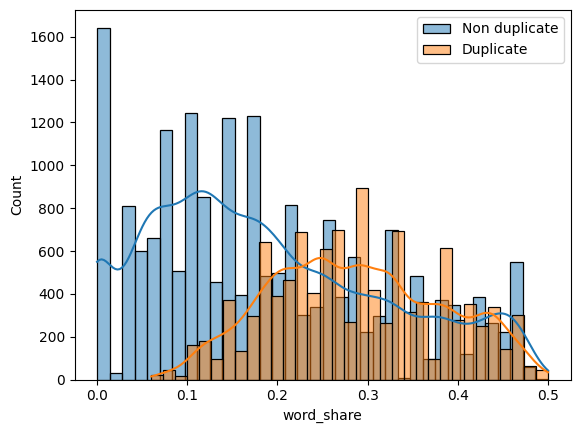

In [ ]:
sns.histplot(new_df[new_df['is_duplicate']==0]['word_share'],label="Non duplicate",kde=True)
sns.histplot(new_df[new_df['is_duplicate']==1]['word_share'],label="Duplicate",kde=True)
plt.legend()
plt.show()


In [ ]:
final_df=new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(30000, 8)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words,word_share
302477,0,33,44,6,9,4,15,0.27
369857,0,25,47,4,9,0,13,0.00
4665,0,125,124,24,24,20,42,0.48
54203,1,45,60,8,10,5,18,0.28
132567,1,71,84,12,14,6,26,0.23


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
questions=list(new_df['question1'])+list(new_df['question2'])
cv=CountVectorizer(max_features=3000)

q1_arr,q2_arr=np.vsplit(cv.fit_transform(questions).toarray(),2)
temp_df1=pd.DataFrame(q1_arr,index=new_df.index)
temp_df2=pd.DataFrame(q2_arr,index=new_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [ ]:
final_df=pd.concat([final_df,temp_df],axis=1)
final_df.shape

(30000, 6008)

In [ ]:
final_df.sample(5)

,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
171701,1,39,51,8,9,5,17,0.29,0,0,...,0,0,0,0,0,0,0,0,0,0
185254,0,44,66,9,14,4,22,0.18,0,0,...,0,0,0,0,0,0,0,0,0,0
196119,0,66,33,12,7,1,19,0.05,0,0,...,0,0,0,0,0,0,0,0,0,0
191097,0,37,37,8,9,4,17,0.24,0,0,...,0,0,1,0,0,0,0,0,0,0
165948,0,32,36,7,7,4,14,0.29,0,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((24000, 6007), (6000, 6007), (24000,), (6000,))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,classification_report,confusion_matrix
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
print("Accuracy score",accuracy_score(y_test,y_pred))
print("Precision score",precision_score(y_test,y_pred))
print("Confusion matrix",confusion_matrix(y_test,y_pred))
print("Classification report",classification_report(y_test,y_pred))


Accuracy score 0.768
Precision score 0.7276376146788991
Confusion matrix [[3339  475]
 [ 917 1269]]
Classification report               precision    recall  f1-score   support

           0       0.78      0.88      0.83      3814
           1       0.73      0.58      0.65      2186

    accuracy                           0.77      6000
   macro avg       0.76      0.73      0.74      6000
weighted avg       0.76      0.77      0.76      6000



In [ ]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)
print("Accuracy score",accuracy_score(y_test,y_pred))
print("Precision score",precision_score(y_test,y_pred))
print("Confusion matrix",confusion_matrix(y_test,y_pred))
print("Classification report",classification_report(y_test,y_pred))

Accuracy score 0.7736666666666666
Precision score 0.6938202247191011
Confusion matrix [[3160  654]
 [ 704 1482]]
Classification report               precision    recall  f1-score   support

           0       0.82      0.83      0.82      3814
           1       0.69      0.68      0.69      2186

    accuracy                           0.77      6000
   macro avg       0.76      0.75      0.75      6000
weighted avg       0.77      0.77      0.77      6000



In [ ]:
# Text preprocessing
# Advanced features
# Token features
# Length based features
# Fuzzy features


### Token Features
Cwc_min:  No. of common words/min(words(q1,q2)

Cwc_max:  No. of common words/max(words(q1,q2)

Csc_min:  No. of common stopwords/min(stopwords(q1,q2)

Csc_max:  No. of common stopwords/max(stopwords(q1,q2)

Ctc_min: Csc_min:  No. of common tokens/min(tokens(q1,q2))

Ctc_max: Csc_min:  No. of common tokens/max(tokens(q1,q2))

last_word_eq:equality between last words of sentence

first_word_eq: equality between first words of sentence

### Length based features

mean_len: No. of total tokens mean

abs_len_diff: Absolute difference between length of sentence

longest_substr_ratio: common words substring/ min(length of words in q1,q2)

### Fuzzy features

fuzz_ratio: fuzz_ratio scire from fuzzywuzzy

fuzz_partial_ratio: fuzz_partial_ratio from fuzzywuzzy

token_sort_ratio: token_sort_ratio from fuzzywuzzy

token_set_ratio: token_set_ratio from fuzzywuzzy






In [ ]:
new_df=df.sample(30000,random_state=2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
339499,339499,665522,665523,Why was Cyrus Mistry removed as the Chairman o...,Why did the Tata Sons sacked Cyrus Mistry?,1
289521,289521,568878,568879,By what age would you think a man should be ma...,When my wrist is extended I feel a shock and b...,0
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0
54203,54203,107861,107862,Why did Quora mark my question as incomplete?,Why does Quora detect my question as an incomp...,1
132566,132566,262554,91499,What is it like working with Pivotal Labs as a...,What's it like to work at Pivotal Labs?,0


In [ ]:
def preprocess(q):
  q=str(q).lower().strip()

  q=q.replace('%','percent')
  q=q.replace('$','dollar')
  q=q.replace('₹','rupee')
  q=q.replace('€','euro')
  q=q.replace('@',"at")

  q=q.replace('[math]','')
  q=q.replace(',000,000,000','b ')
  q=q.replace(',000,000','m ')
  q=q.replace(',000','k ')
  q=re.sub(r'([0-9]+)000000000',r'\1b',q)
  q=re.sub(r'([0-9]+)000000',r'\1m',q)
  q=re.sub(r'([0-9]+)000',r'\1k',q)

  #decontracting words
  # Source - https://stackoverflow.com/a/19794953
# Posted by arturomp, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-02, License - CC BY-SA 3.0

  contractions = {
"ain't": "am not / are not / is not / has not / have not",
"aren't": "are not / am not",
"can't": "cannot",
"can't've": "cannot have",
"'cause": "because",
"could've": "could have",
"couldn't": "could not",
"couldn't've": "could not have",
"didn't": "did not",
"doesn't": "does not",
"don't": "do not",
"hadn't": "had not",
"hadn't've": "had not have",
"hasn't": "has not",
"haven't": "have not",
"he'd": "he had / he would",
"he'd've": "he would have",
"he'll": "he shall / he will",
"he'll've": "he shall have / he will have",
"he's": "he has / he is",
"how'd": "how did",
"how'd'y": "how do you",
"how'll": "how will",
"how's": "how has / how is / how does",
"I'd": "I had / I would",
"I'd've": "I would have",
"I'll": "I shall / I will",
"I'll've": "I shall have / I will have",
"I'm": "I am",
"I've": "I have",
"isn't": "is not",
"it'd": "it had / it would",
"it'd've": "it would have",
"it'll": "it shall / it will",
"it'll've": "it shall have / it will have",
"it's": "it has / it is",
"let's": "let us",
"ma'am": "madam",
"mayn't": "may not",
"might've": "might have",
"mightn't": "might not",
"mightn't've": "might not have",
"must've": "must have",
"mustn't": "must not",
"mustn't've": "must not have",
"needn't": "need not",
"needn't've": "need not have",
"o'clock": "of the clock",
"oughtn't": "ought not",
"oughtn't've": "ought not have",
"shan't": "shall not",
"sha'n't": "shall not",
"shan't've": "shall not have",
"she'd": "she had / she would",
"she'd've": "she would have",
"she'll": "she shall / she will",
"she'll've": "she shall have / she will have",
"she's": "she has / she is",
"should've": "should have",
"shouldn't": "should not",
"shouldn't've": "should not have",
"so've": "so have",
"so's": "so as / so is",
"that'd": "that would / that had",
"that'd've": "that would have",
"that's": "that has / that is",
"there'd": "there had / there would",
"there'd've": "there would have",
"there's": "there has / there is",
"they'd": "they had / they would",
"they'd've": "they would have",
"they'll": "they shall / they will",
"they'll've": "they shall have / they will have",
"they're": "they are",
"they've": "they have",
"to've": "to have",
"wasn't": "was not",
"we'd": "we had / we would",
"we'd've": "we would have",
"we'll": "we will",
"we'll've": "we will have",
"we're": "we are",
"we've": "we have",
"weren't": "were not",
"what'll": "what shall / what will",
"what'll've": "what shall have / what will have",
"what're": "what are",
"what's": "what has / what is",
"what've": "what have",
"when's": "when has / when is",
"when've": "when have",
"where'd": "where did",
"where's": "where has / where is",
"where've": "where have",
"who'll": "who shall / who will",
"who'll've": "who shall have / who will have",
"who's": "who has / who is",
"who've": "who have",
"why's": "why has / why is",
"why've": "why have",
"will've": "will have",
"won't": "will not",
"won't've": "will not have",
"would've": "would have",
"wouldn't": "would not",
"wouldn't've": "would not have",
"y'all": "you all",
"y'all'd": "you all would",
"y'all'd've": "you all would have",
"y'all're": "you all are",
"y'all've": "you all have",
"you'd": "you had / you would",
"you'd've": "you would have",
"you'll": "you shall / you will",
"you'll've": "you shall have / you will have",
"you're": "you are",
"you've": "you have"
}
  q_contracted=[]
  for word in q.split():
    if word in contractions:
      word=contractions[word]

    q_contracted.append(word)
  q=' '.join(q_contracted)
  q=q.replace("'ve","have")
  q=q.replace("'re","are")
  q=q.replace("'ll","will")
  q=q.replace("n't","not")

  #Remove HTML tags
  q=BeautifulSoup(q)
  q=q.get_text()

  #Remove punctuations
  pattern=re.compile('\W')

  q=re.sub(pattern,' ',q).strip()
  return q





<>:159: SyntaxWarning: invalid escape sequence '\W'
<>:159: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_20362/2386545667.py:159: SyntaxWarning: invalid escape sequence '\W'
  pattern=re.compile('\W')


In [ ]:
preprocess("I've already borrowed $100 . I wasn't <b>done</b>? ")



'ihave already borrowed dollar100   i was not done'

In [ ]:
new_df['question1']=new_df['question1'].apply(preprocess)
new_df['question2']=new_df['question2'].apply(preprocess)

In [ ]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
339499,339499,665522,665523,why was cyrus mistry removed as the chairman o...,why did the tata sons sacked cyrus mistry,1
289521,289521,568878,568879,by what age would you think a man should be ma...,when my wrist is extended i feel a shock and b...,0
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1
132566,132566,262554,91499,what is it like working with pivotal labs as a...,what has what is it like to work at pivotal ...,0


In [ ]:
new_df['q1_len']=new_df['question1'].str.len()
new_df['q2_len']=new_df['question2'].str.len()
new_df['q1_num_words']=new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words']=new_df['question2'].apply(lambda row: len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
339499,339499,665522,665523,why was cyrus mistry removed as the chairman o...,why did the tata sons sacked cyrus mistry,1,57,41,11,8
289521,289521,568878,568879,by what age would you think a man should be ma...,when my wrist is extended i feel a shock and b...,0,51,104,11,23
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,123,122,42,42
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,44,59,8,10
132566,132566,262554,91499,what is it like working with pivotal labs as a...,what has what is it like to work at pivotal ...,0,53,50,11,13


In [ ]:
def common_words(q1_str, q2_str):
  w1=set(map(lambda word:word.lower().strip(),q1_str.split(" ")))
  w2=set(map(lambda word:word.lower().strip(),q2_str.split(" ")))
  return len(w1&w2)

In [ ]:
def total_words(q1_str, q2_str):
  w1=set(map(lambda word:word.lower().strip(), q1_str.split(" ")))
  w2=set(map(lambda word:word.lower().strip(), q2_str.split(" ")))
  return (len(w1)+len(w2))

In [ ]:
new_df['word_share']=round(new_df['common_words']/new_df['total_words'],2)
new_df.head()


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words,word_share
339499,339499,665522,665523,why was cyrus mistry removed as the chairman o...,why did the tata sons sacked cyrus mistry,1,57,41,11,8,6,19,0.32
289521,289521,568878,568879,by what age would you think a man should be ma...,when my wrist is extended i feel a shock and b...,0,51,104,11,23,3,33,0.09
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,123,122,42,42,18,38,0.47
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,44,59,8,10,6,18,0.33
132566,132566,262554,91499,what is it like working with pivotal labs as a...,what has what is it like to work at pivotal ...,0,53,50,11,13,6,22,0.27


In [ ]:
from nltk.corpus import stopwords
def fetch_token_features(q1, q2):
  safe_div=0.0001
  stop_words=stopwords.words('english')
  token_features=[0.0]*8

  q1_tokens=q1.split()
  q2_tokens=q2.split()

  if len(q1_tokens)==0 or len(q2_tokens)==0:
    return token_features

  q1_words=set([word for word in q1_tokens if word not in stop_words])
  q2_words=set([word for word in q2_tokens if word not in stop_words])

  q1_stops=set([word for word in q1_tokens if word in stop_words])
  q2_stops=set([word for word in q2_tokens if word in stop_words])

#Get common non-stopwords from question pair
  common_word_count=len(q1_words.intersection(q2_words))
  common_stop_count=len(q1_stops.intersection(q2_stops))

  token_features[0]=common_word_count/(min(len(q1_words),len(q2_words))+safe_div)
  token_features[1]=common_word_count/(max(len(q1_words),len(q2_words))+safe_div)
  token_features[2]=common_stop_count/(min(len(q1_stops),len(q2_stops))+safe_div)
  token_features[3]=common_stop_count/(max(len(q1_stops),len(q2_stops))+safe_div)
  token_features[4]=common_stop_count/(min(len(q1_tokens),len(q2_tokens))+safe_div)
  token_features[5]=common_stop_count/(max(len(q1_tokens),len(q2_tokens))+safe_div)

  #Last word of both questions is same or not
  token_features[6]=int(q1_tokens[-1]==q2_tokens[-1])

  #First word of both questions is same or not
  token_features[7]=int(q1_tokens[0]==q2_tokens[0])

  return token_features

In [ ]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,total_words,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
339499,339499,665522,665523,why was cyrus mistry removed as the chairman o...,why did the tata sons sacked cyrus mistry,1,57,41,11,8,...,19,0.32,0.799984,0.666656,0.666644,0.399992,0.249997,0.181817,0,1
289521,289521,568878,568879,by what age would you think a man should be ma...,when my wrist is extended i feel a shock and b...,0,51,104,11,23,...,33,0.09,0.000000,0.000000,0.499992,0.272725,0.272725,0.136363,0,0
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,123,122,42,42,...,38,0.47,0.923070,0.923070,0.999980,0.999980,0.208332,0.208332,1,1
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,44,59,8,10,...,18,0.33,0.749981,0.599988,0.749981,0.599988,0.374995,0.299997,0,1
132566,132566,262554,91499,what is it like working with pivotal labs as a...,what has what is it like to work at pivotal ...,0,53,50,11,13,...,22,0.27,0.749981,0.599988,0.499992,0.499992,0.272725,0.272725,0,1


In [ ]:
!pip install distance

In [ ]:
import distance
def fetch_length_features(q1, q2):
  length_features=[0.0]*3
  # converting the sentence into tokens
  q1_tokens=q1.split()
  q2_tokens=q2.split()
  if len(q1_tokens)==0 or len(q2_tokens)==0:
    return length_features
  length_features[0]=abs(len(q1_tokens)-len(q2_tokens))

  #avg length of tokens of both questions

  length_features[1]=((len(q1_tokens)+len(q2_tokens))/2)

  str_lcs=list(distance.lcsubstrings(q1,q2))
  length_features[2]=len(str_lcs[0])/(min(len(q1),len(q2))+1)

  return length_features

In [ ]:
length_features = new_df.apply(lambda row: fetch_length_features(row['question1'], row['question2']), axis=1)

new_df['abs_len_diff']=list(map(lambda x:x[0],length_features))
new_df['mean_len']=list(map(lambda x:x[1],length_features))
new_df['longest_substring_ratio']=list(map(lambda x:x[2],length_features))

new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substring_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
339499,339499,665522,665523,why was cyrus mistry removed as the chairman o...,why did the tata sons sacked cyrus mistry,1,57,41,11,8,...,0.181817,0,1,3,9.5,0.309524,39,46,67,85
289521,289521,568878,568879,by what age would you think a man should be ma...,when my wrist is extended i feel a shock and b...,0,51,104,11,23,...,0.136363,0,0,11,16.5,0.115385,26,50,35,37
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,123,122,42,42,...,0.208332,1,1,0,24.0,0.593496,100,99,100,99
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,44,59,8,10,...,0.299997,0,1,2,9.0,0.355556,74,75,74,89
132566,132566,262554,91499,what is it like working with pivotal labs as a...,what has what is it like to work at pivotal ...,0,53,50,11,13,...,0.272725,0,1,0,11.0,0.313725,68,70,81,83


In [ ]:
!pip install fuzzywuzzy

In [ ]:
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(q1, q2):
  fuzzy_features=[0.0]*4
  fuzzy_features[0]=fuzz.ratio(q1,q2)

  fuzzy_features[1]=fuzz.partial_ratio(q1,q2)

  fuzzy_features[2]=fuzz.token_sort_ratio(q1,q2)

  fuzzy_features[3]=fuzz.token_set_ratio(q1,q2)

  return fuzzy_features

In [ ]:
fuzzy_features=new_df.apply(lambda row: fetch_fuzzy_features(row['question1'], row['question2']), axis=1)

new_df['fuzz_ratio']=list(map(lambda x:x[0],fuzzy_features))
new_df['fuzz_partial_ratio']=list(map(lambda x:x[1],fuzzy_features))
new_df['token_sort_ratio']=list(map(lambda x:x[2],fuzzy_features))
new_df['token_set_ratio']=list(map(lambda x:x[3],fuzzy_features))

new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substring_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
339499,339499,665522,665523,why was cyrus mistry removed as the chairman o...,why did the tata sons sacked cyrus mistry,1,57,41,11,8,...,0.181817,0,1,3,9.5,0.309524,39,46,67,85
289521,289521,568878,568879,by what age would you think a man should be ma...,when my wrist is extended i feel a shock and b...,0,51,104,11,23,...,0.136363,0,0,11,16.5,0.115385,26,50,35,37
4665,4665,9325,9326,how would an arbitrageur seek to capitalize gi...,how would an arbitrageur seek to capitalize gi...,0,123,122,42,42,...,0.208332,1,1,0,24.0,0.593496,100,99,100,99
54203,54203,107861,107862,why did quora mark my question as incomplete,why does quora detect my question as an incomp...,1,44,59,8,10,...,0.299997,0,1,2,9.0,0.355556,74,75,74,89
132566,132566,262554,91499,what is it like working with pivotal labs as a...,what has what is it like to work at pivotal ...,0,53,50,11,13,...,0.272725,0,1,0,11.0,0.313725,68,70,81,83


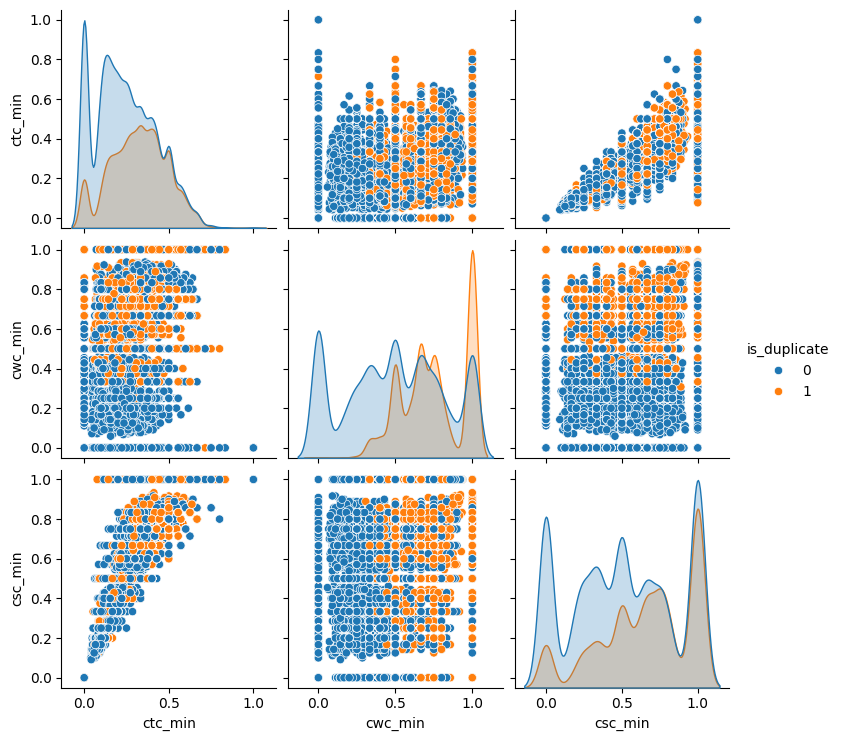

In [ ]:
# Pairplot
sns.pairplot(new_df[['ctc_min','cwc_min','csc_min','is_duplicate']],hue='is_duplicate')

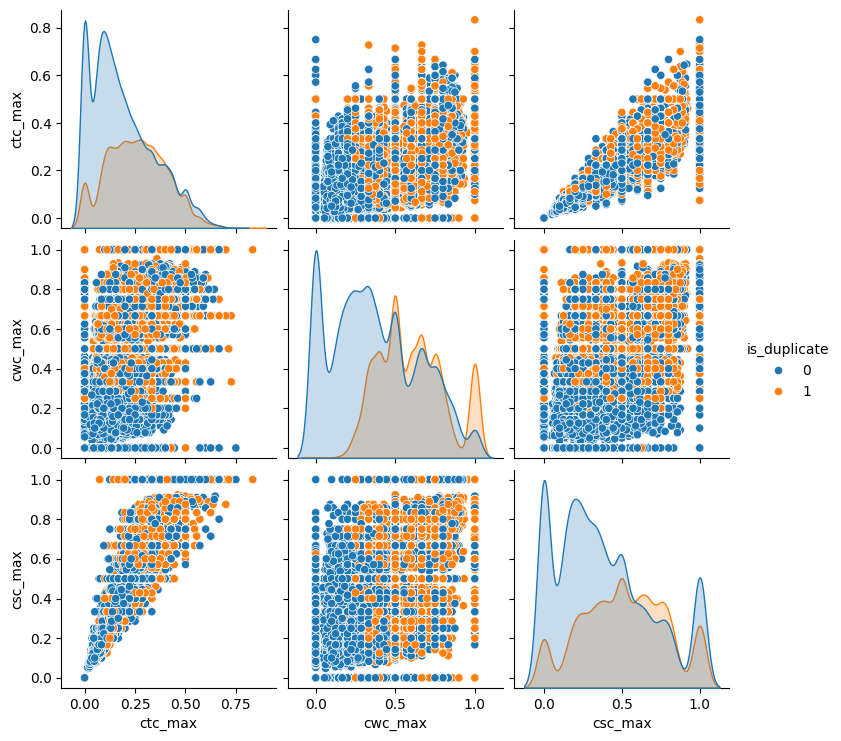

In [ ]:
sns.pairplot(new_df[['ctc_max','cwc_max','csc_max','is_duplicate']],hue='is_duplicate')


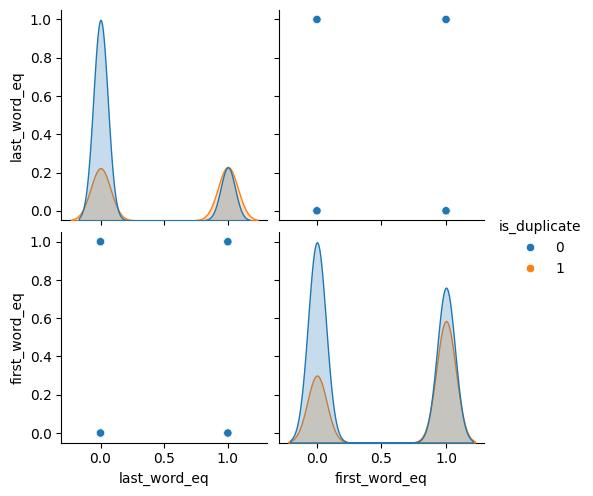

In [ ]:
sns.pairplot(new_df[['last_word_eq','first_word_eq','is_duplicate']],hue='is_duplicate')

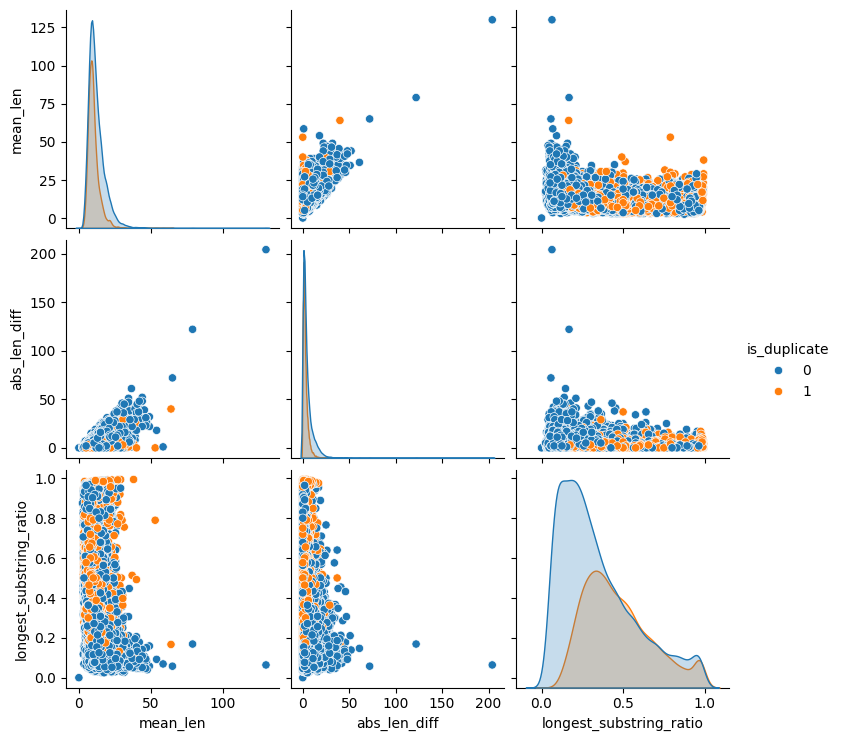

In [ ]:
sns.pairplot(new_df[['mean_len','abs_len_diff','longest_substring_ratio','is_duplicate']],hue='is_duplicate')

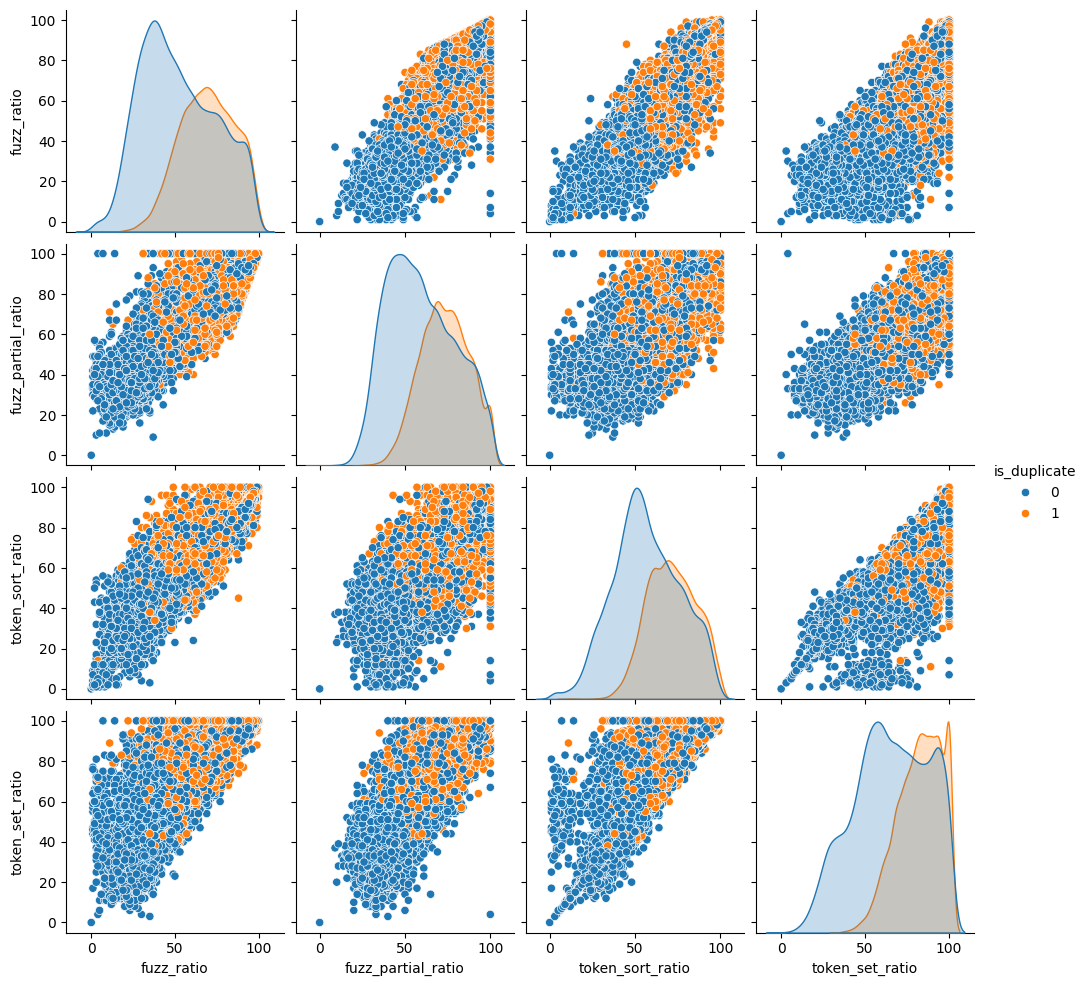

In [ ]:
sns.pairplot(new_df[['fuzz_ratio','fuzz_partial_ratio','token_sort_ratio','token_set_ratio','is_duplicate']],hue='is_duplicate')

In [ ]:
# Using TSNE for dimesionality reduction for 15 features (Generated after cleaning the data) to 3 dimension
from sklearn.preprocessing import MinMaxScaler
x=MinMaxScaler().fit_transform(new_df[['cwc_min','cwc_max','csc_min','csc_max','ctc_min','ctc_max','last_word_eq','first_word_eq','mean_len','abs_len_diff','longest_substring_ratio','fuzz_ratio','fuzz_partial_ratio','token_sort_ratio','token_set_ratio']])
y=new_df['is_duplicate'].values

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.295s...
[t-SNE] Computed neighbors for 30000 samples in 17.826s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sa

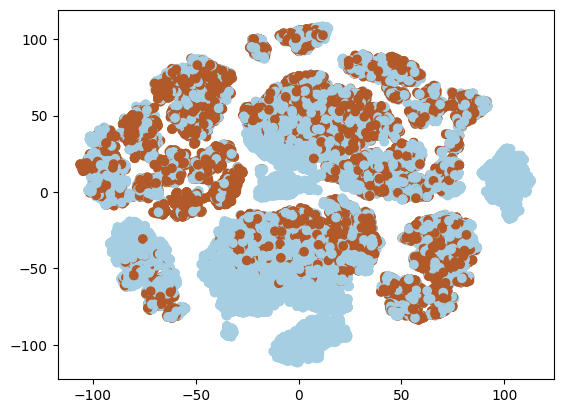

In [ ]:
from sklearn.manifold import TSNE
tsne2d=TSNE(n_components=2,init='random',
            random_state=101, method='barnes_hut',
            n_iter=1000,verbose=2,
            angle=0.5).fit_transform(x)
#plot the graph
plt.scatter(tsne2d[:,0],tsne2d[:,1],c=y,cmap='Paired')

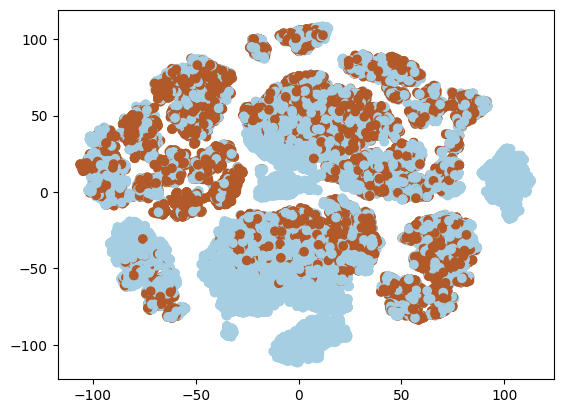

In [ ]:
plt.scatter(tsne2d[:,0],tsne2d[:,1],c=y,cmap='Paired')

In [ ]:
tsne3d=TSNE(n_components=3,init='random',
            random_state=101,method='barnes_hut',
            n_iter=1000,verbose=2,
            angle=0.5).fit_transform(x)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.081s...
[t-SNE] Computed neighbors for 30000 samples in 8.510s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

In [ ]:
# Plot the 3D graph on 3 dimensional Space using plotly
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.offline as py
import plotly.express as px
px.scatter_3d(tsne3d,x=tsne3d[0],y=tsne3d[1],z=tsne3d[2])

In [ ]:
ques_df=new_df[['question1','question2']]
ques_df.head()
final_df=new_df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)

final_df.head()

(30000, 23)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substring_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
339499,1,57,41,11,8,6,19,0.32,0.799984,0.666656,...,0.181817,0,1,3,9.5,0.309524,39,46,67,85
289521,0,51,104,11,23,3,33,0.09,0.000000,0.000000,...,0.136363,0,0,11,16.5,0.115385,26,50,35,37
4665,0,123,122,42,42,18,38,0.47,0.923070,0.923070,...,0.208332,1,1,0,24.0,0.593496,100,99,100,99
54203,1,44,59,8,10,6,18,0.33,0.749981,0.599988,...,0.299997,0,1,2,9.0,0.355556,74,75,74,89
132566,0,53,50,11,13,6,22,0.27,0.749981,0.599988,...,0.272725,0,1,0,11.0,0.313725,68,70,81,83


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
questions=list(ques_df['question1'])+list(ques_df['question2'])
cv=CountVectorizer(max_features=3000)
q1_arr,q2_arr=np.vsplit(cv.fit_transform(questions).toarray(),2)

In [ ]:
temp_df1=pd.DataFrame(q1_arr,index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr,index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)
temp_df.shape

(30000, 6000)

In [ ]:
final_df=pd.concat([final_df,temp_df],axis=1)
print(final_df.shape)
final_df.sample(5)

(30000, 6023)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,total_words,word_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
308890,1,36,33,8,8,7,16,0.44,0.749981,0.749981,...,0,0,0,0,0,0,0,0,0,0
145314,0,149,81,27,14,1,37,0.03,0.000000,0.000000,...,0,0,1,0,0,0,0,0,0,0
271339,0,120,121,27,26,11,46,0.24,0.499996,0.461535,...,0,0,0,0,0,0,0,0,0,0
313744,0,47,48,8,8,5,16,0.31,0.599988,0.599988,...,0,0,0,0,0,0,0,0,0,0
830,1,26,39,7,10,5,15,0.33,0.499975,0.249994,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=2)

In [ ]:
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7993333333333333

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Confusion matrix",confusion_matrix(y_test,y_pred))
print("Classification report",classification_report(y_test,y_pred))

Accuracy: 0.7993333333333333
Precision: 0.7445436507936508
Confusion matrix [[3295  515]
 [ 689 1501]]
Classification report               precision    recall  f1-score   support

           0       0.83      0.86      0.85      3810
           1       0.74      0.69      0.71      2190

    accuracy                           0.80      6000
   macro avg       0.79      0.78      0.78      6000
weighted avg       0.80      0.80      0.80      6000



In [ ]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)


In [ ]:
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Confusion matrix",confusion_matrix(y_test,y_pred))
print("Classification report",classification_report(y_test,y_pred))

Accuracy 0.792
Precision 0.7184601113172542
Confusion matrix [[3203  607]
 [ 641 1549]]
Classification report               precision    recall  f1-score   support

           0       0.83      0.84      0.84      3810
           1       0.72      0.71      0.71      2190

    accuracy                           0.79      6000
   macro avg       0.78      0.77      0.77      6000
weighted avg       0.79      0.79      0.79      6000



In [ ]:
# Increase the data - Increase the RAM or cloud platform or use batches or incremental learning such as vaex library or Dask
# Preprocessing- stemming or Lemmatization -Use stemming
# Apply more algorithms or do hyperparameter tuning
# More features
# Bag of word or tfidf, word2vec, tfidf weighted w2v
# Deep learning - Build in data loaders so you can use whole data in one go


In [ ]:
# Website serve and deploy using heroku
# Input two questions and predict matching but the shape should be 1, 6022 -> 22 features created and 3000 features of Question 1 and 3000 features of question 2
def query_point_creator(q1,q2):
  input_query=[]

  q1=preprocess(q1)
  q2=preprocess(q2)

  # Fetch basic features

  input_query.append(len(q1))
  input_query.append(len(q2))

  input_query.append(len(q1.split(" ")))
  input_query.append(len(q2.split(" ")))

  input_query.append(common_words(q1,q2))
  input_query.append(total_words(q1,q2))
  input_query.append(round(common_words(q1,q2)/total_words(q1,q2),2)) # Corrected round function call

  # Fetch token features
  token_features=fetch_token_features(q1,q2)
  input_query.extend(token_features)

  # Fetch length features

  length_features=fetch_length_features(q1,q2)
  input_query.extend(length_features)

  # Fetch fuzzy feature

  fuzzy_features=fetch_fuzzy_features(q1,q2)
  input_query.extend(fuzzy_features)

  # Vectorize the questions

  q1_bow=cv.transform([q1]).toarray()
  q2_bow=cv.transform([q2]).toarray()


  return np.hstack((np.array(input_query).reshape(1,22),q1_bow,q2_bow))

In [ ]:
q1="what is the capital of India?"
q2="what is the current capital of India?"

query_point_creator(q1,q2)

array([[28., 36.,  6., ...,  0.,  0.,  0.]])

In [ ]:
query_point_creator(q1,q2).shape

(1, 6022)

In [ ]:
rf.predict(query_point_creator(q1,q2))

array([1])

In [ ]:
import pickle
pickle.dump(rf,open('model.pkl','wb'))
pickle.dump(cv,open('cv.pkl','wb'))

In [ ]:
import os

os.makedirs("project", exist_ok=True)